In [14]:
import sys 
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../")

from oxels.augmentation import HueShift, MotionBlur, RandomKernel, RandomBrightnessContrast, PixelNoise, Sobel, Scharr, SequenceStrategy

In [11]:
#"harmless" augmentations
basic_augmentations = SequenceStrategy(
    [MotionBlur(), HueShift(), RandomBrightnessContrast()],
    probabilities=[0.8,0.8,0.8],
    ordered=False,
    at_most_one=False)

#more disruptive augmentations that should be applied sparsingly and collide with one another
advanced_agumentation = SequenceStrategy(
    [RandomKernel(), Sobel(), Scharr(), PixelNoise()],
    probabilities=None,
    ordered=False,
    at_most_one=True)

#all augmentations (order matters)
all_agumentations = SequenceStrategy(
    [basic_augmentations, advanced_agumentation],
    probabilities=[1.0, 0.2],
    ordered=True,
    at_most_one=False)

In [12]:
im = np.load("../../telescope/validation_data/Screencastfrom05-13-2024045817PM.webm/153_99_4_1.02105_0.15949_-0.11547_0.64957_-0.22244_-0.13525.npy")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..6.369609].


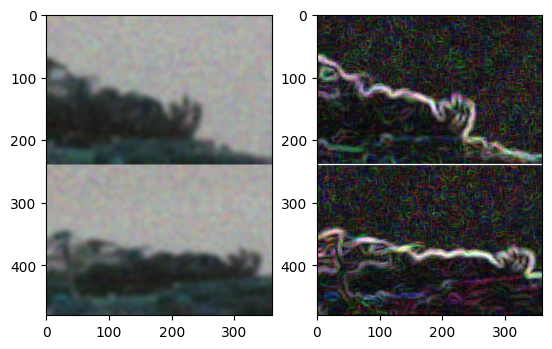

In [58]:
plt.subplot(121)
plt.imshow(im)
plt.subplot(122)
plt.imshow(all_agumentations(im))